In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Load Dataset

In [2]:
transform = transforms.Compose([
    transforms.ToTensor()   # values in [0,1]
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

beta = noise amount
alpha = remaining signal
alpha_bar = total remaining signal after many steps

In [3]:
T = 100  # total steps

beta = torch.linspace(1e-4, 0.02, T).to(device)
alpha = 1. - beta
alpha_bar = torch.cumprod(alpha, dim=0)

takes clean image and adds noise 
returns noisy image and actual noise

In [4]:
def add_noise(x, t):
    noise = torch.randn_like(x)

    alpha_bar_t = alpha_bar[t].view(-1, 1, 1, 1)

    x_t = torch.sqrt(alpha_bar_t) * x + torch.sqrt(1 - alpha_bar_t) * noise

    return x_t, noise

model

In [5]:
class DiffusionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, 3, padding=1)
        )

    def forward(self, x, t):
        return self.net(x)

In [6]:
model = DiffusionModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

training

In [7]:
epochs = 20

for epoch in range(epochs):
    for x, _ in train_loader:
        x = x.to(device)

        # pick random timestep
        t = torch.randint(0, T, (x.size(0),), device=device)

        # add noise
        x_t, noise = add_noise(x, t)

        # predict noise
        pred_noise = model(x_t, t)

        # loss
        loss = F.mse_loss(pred_noise, noise)

        # update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.1020
Epoch 2, Loss: 0.0858
Epoch 3, Loss: 0.0826
Epoch 4, Loss: 0.0759
Epoch 5, Loss: 0.0742
Epoch 6, Loss: 0.0825
Epoch 7, Loss: 0.0728
Epoch 8, Loss: 0.0668
Epoch 9, Loss: 0.0699
Epoch 10, Loss: 0.0712
Epoch 11, Loss: 0.0710
Epoch 12, Loss: 0.0686
Epoch 13, Loss: 0.0660
Epoch 14, Loss: 0.0721
Epoch 15, Loss: 0.0702
Epoch 16, Loss: 0.0657
Epoch 17, Loss: 0.0607
Epoch 18, Loss: 0.0619
Epoch 19, Loss: 0.0648
Epoch 20, Loss: 0.0644


generate image

In [10]:
@torch.no_grad()
def sample(model, n=20):
    model.eval()

    # start from random noise
    x = torch.randn((n, 1, 28, 28)).to(device)

    for t in reversed(range(T)):
        t_tensor = torch.full((n,), t, device=device)

        beta_t = beta[t]
        alpha_t = alpha[t]
        alpha_bar_t = alpha_bar[t]

        pred_noise = model(x, t_tensor)

        x = (1 / torch.sqrt(alpha_t)) * (
            x - (beta_t / torch.sqrt(1 - alpha_bar_t)) * pred_noise
        )

        if t > 0:
            noise = torch.randn_like(x)
            x += torch.sqrt(beta_t) * noise

    return x

visualise

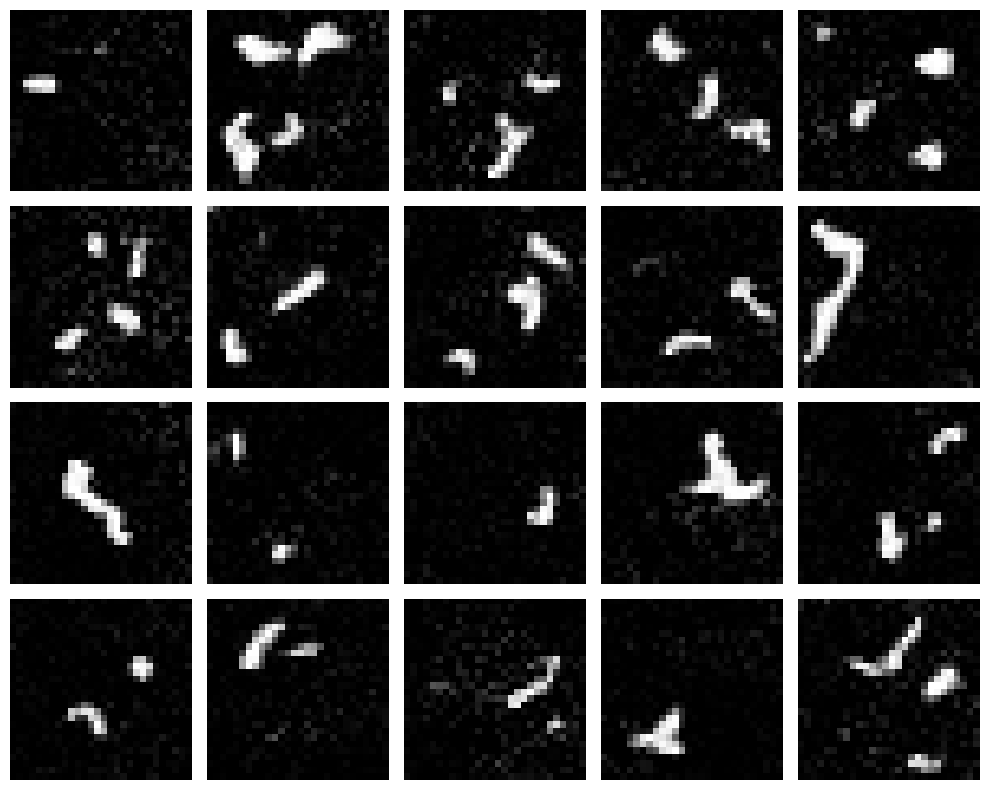

In [18]:
samples = sample(model)
samples = samples.clamp(0, 1).cpu()

fig, axes = plt.subplots(4, 5, figsize=(10, 8))
axes = axes.flatten()   

for i in range(20):
    axes[i].imshow(samples[i].squeeze(), cmap="gray")
    axes[i].axis("off")

plt.tight_layout()
plt.show()